# 🧪 Data Science Practical (Advanced)

## Experiment No: 5
## Experiment Title: Advanced Regression — Model Comparison & Residual Analysis

**Name:** Himanshu Jadhav  
**Roll Number:** SE-33  

---

## Problem Statement

Build and compare Linear Regression, Ridge, and Lasso models on the Boston Housing dataset. Evaluate using R², MSE, K-Fold cross-validation, and residual analysis.

**Dataset:** [Boston Housing Dataset — Kaggle](https://www.kaggle.com/datasets/altavish/boston-housing-datase)

---

## Implementation

## Step 0: Imports & Theme

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn — preprocessing
from sklearn.model_selection   import train_test_split, KFold, cross_val_score
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute            import SimpleImputer

# sklearn — models
from sklearn.linear_model      import LinearRegression, Ridge, Lasso

# sklearn — evaluation
from sklearn.metrics           import r2_score, mean_squared_error, mean_absolute_error

# scipy for statistical tests on residuals
from scipy                     import stats

np.random.seed(42)

# ── Global dark theme ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#080816',
    'axes.facecolor'   : '#0f0f28',
    'axes.edgecolor'   : '#222248',
    'axes.labelcolor'  : '#b0b0d0',
    'xtick.color'      : '#777790',
    'ytick.color'      : '#777790',
    'text.color'       : 'white',
    'grid.color'       : '#18183a',
    'grid.linewidth'   : 0.5,
    'legend.facecolor' : '#0f0f28',
    'legend.edgecolor' : '#222248',
})
PAL   = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']
MPAL  = {'Linear Regression': PAL[1], 'Ridge': PAL[2], 'Lasso': PAL[0]}
print('Imports ready...')

Imports ready...


## Part 1: Load Dataset

In [2]:
df_raw = pd.read_csv('HousingData.csv')

print(f'Shape    : {df_raw.shape}')
print(f'Target   : MEDV (Median House Value, $100k)')
print(f'Nulls    : {df_raw.isnull().sum().sum()}')
print(f'\nDescriptive Stats:')
df_raw.describe().round(2)

Shape    : (506, 14)
Target   : MEDV (Median House Value, $100k)
Nulls    : 120

Descriptive Stats:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.00,486.00,486.00,486.00,506.00,506.00,486.00,506.00,506.00,506.00,506.00,506.00,486.00,506.00
mean,3.61,11.21,11.08,0.07,0.55,6.28,68.52,3.80,9.55,408.24,18.46,356.67,12.72,22.53
std,8.72,23.39,6.84,0.26,0.12,0.70,28.00,2.11,8.71,168.54,2.16,91.29,7.16,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.18,2.10,4.00,279.00,17.40,375.38,7.12,17.02
50%,0.25,0.00,9.69,0.00,0.54,6.21,76.80,3.21,5.00,330.00,19.05,391.44,11.43,21.20
75%,3.56,12.50,18.10,0.00,0.62,6.62,93.98,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


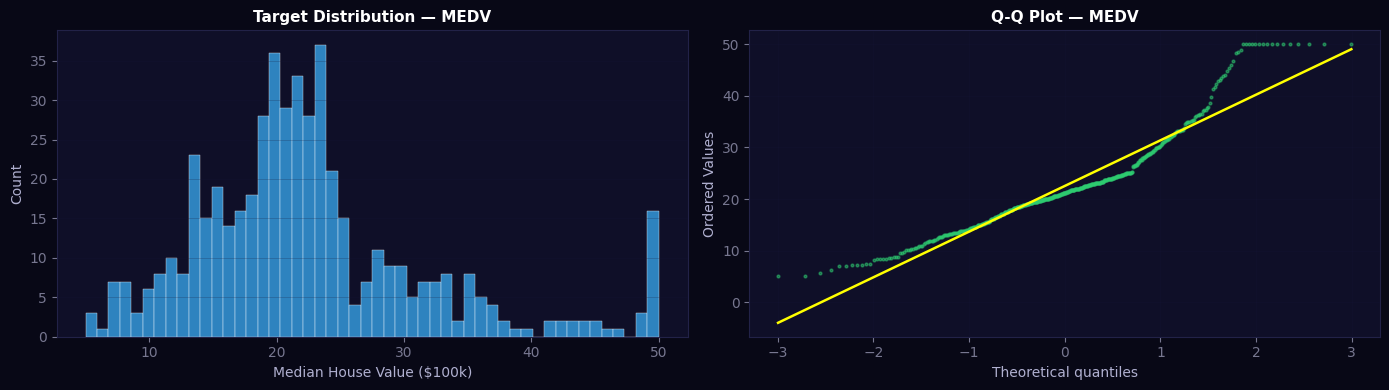

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#080816')

axes[0].hist(df_raw['MEDV'], bins=50, color=PAL[1], edgecolor='white', lw=0.3, alpha=0.85)
axes[0].set_title('Target Distribution — MEDV', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].grid(True, axis='y', alpha=0.3)

stats.probplot(df_raw['MEDV'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — MEDV', fontsize=11, fontweight='bold')
axes[1].get_lines()[0].set(color=PAL[2], markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color='yellow', lw=1.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2: Preprocessing - Feature Selection & Standardisation 

In [4]:
X_all = df_raw.drop(columns=['MEDV'])
y     = df_raw['MEDV']

print(f"All features ({len(X_all.columns)}): {list(X_all.columns)}")

All features (13): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [5]:
imputer = SimpleImputer(strategy='mean')
X_all_imputed = imputer.fit_transform(X_all)

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_all_imputed, y)

feat_scores = pd.DataFrame({
    'Feature': X_all.columns,
    'F-Score': selector.scores_.round(2),
    'p-value': selector.pvalues_.round(4)
}).sort_values('F-Score', ascending=False)

print('Feature Ranking by F-Score:')
print(feat_scores.to_string(index=False))


Feature Ranking by F-Score:
Feature  F-Score  p-value
  LSTAT   548.74      0.0
     RM   471.85      0.0
PTRATIO   175.11      0.0
  INDUS   149.79      0.0
    TAX   141.76      0.0
    NOX   112.59      0.0
    RAD    85.91      0.0
    AGE    85.18      0.0
   CRIM    84.90      0.0
     ZN    77.93      0.0
      B    63.05      0.0
    DIS    33.58      0.0
   CHAS    16.85      0.0


Selected top-6 features: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']


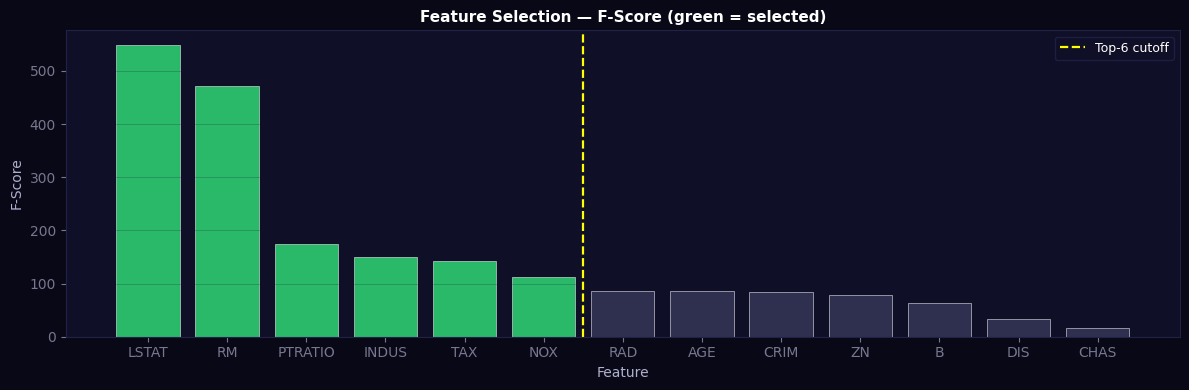

In [6]:
TOP_K    = 6
top_feats = feat_scores.head(TOP_K)['Feature'].tolist()
X         = X_all[top_feats].copy()

print(f'Selected top-{TOP_K} features: {top_feats}')

# ── F-score bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#080816')
bars = ax.bar(feat_scores['Feature'], feat_scores['F-Score'],
              color=[PAL[2] if f in top_feats else '#333355' for f in feat_scores['Feature']],
              edgecolor='white', lw=0.4, alpha=0.9)
ax.axvline(TOP_K - 0.5, color='yellow', ls='--', lw=1.6, label=f'Top-{TOP_K} cutoff')
ax.set_title('Feature Selection — F-Score (green = selected)', fontsize=11, fontweight='bold')
ax.set_ylabel('F-Score')
ax.set_xlabel('Feature')
ax.legend(fontsize=9, labelcolor='white')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'y_train — mean={y_train.mean():.3f}, std={y_train.std():.3f}')

Train : (404, 6)  |  Test : (102, 6)
y_train — mean=22.797, std=9.332


## Part 3: Model Training - sklearn Pipelines

In [8]:
pipelines = {
    'Linear Regression' : Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model' , LinearRegression())
    ]),
    'Ridge' : Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler' , StandardScaler()),
        ('model'  , Ridge(alpha=1.6, random_state=42))
    ]),
    'Lasso' : Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('model' , Lasso(alpha=0.1, max_iter=10000, random_state=42))
    ]),
}

predictions = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    predictions[name] = pipe.predict(X_test)
    print(f'{name} trained...')

Linear Regression trained...
Ridge trained...
Lasso trained...


## Part 4: Evaluation — R², MSE, MAE, RMSE

In [9]:
def eval_regression(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    return {
        'Model' : name,
        'R²'    : round(r2_score(y_true, y_pred),            4), # R²   (Coefficient of Determination)
        'MSE'   : round(mse,                                 4), # MSE  (Mean Squared Error)
        'RMSE'  : round(np.sqrt(mse),                        4), # RMSE (Root Mean Squared Error)
        'MAE'   : round(mean_absolute_error(y_true, y_pred), 4), # MAE  (Mean Absolute Error)
    }

results = pd.DataFrame([
    eval_regression(name, y_test, predictions[name])
    for name in pipelines
]).set_index('Model')

print('=' * 62)
print('  Test Set Evaluation Summary')
print('=' * 62)
print(results.to_string())
print('=' * 62)
best_r2  = results['R²'].idxmax()
best_mse = results['MSE'].idxmin()
print(f'  Best R²   → {best_r2}')
print(f'  Lowest MSE → {best_mse}')
print('=' * 62)

  Test Set Evaluation Summary
                       R²      MSE    RMSE     MAE
Model                                             
Linear Regression  0.6200  27.8702  5.2792  3.2961
Ridge              0.6205  27.8276  5.2752  3.2943
Lasso              0.6239  27.5799  5.2517  3.2799
  Best R²   → Lasso
  Lowest MSE → Lasso


## Part 5: K-Fold Cross-Validation (*k=10*)

In [10]:
# 10-Fold CV on all three pipelines

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}
print(f"{'Model':<22} {'CV R² Scores':>50}   Mean ± Std")
print('-' * 82)
for name, pipe in pipelines.items():
    cv_r2 = cross_val_score(pipe, X, y, scoring='r2')
    cv_mse = -cross_val_score(pipe, X, y, scoring='neg_mean_squared_error')
    cv_results[name] = {'r2' : cv_r2, 'mse' : cv_mse}
    scores_str = np.array2string(cv_r2.round(3), separator=',', suppress_small=True)
    print(f"{name:<22} {scores_str:>50}   {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

print()
print(f"{'Model':<22} {'CV MSE Mean':>15} {'CV MSE Std':>15}")
print('-' * 55)
for name in pipelines:
    mse_arr = cv_results[name]['mse']
    print(f"{name:<22} {mse_arr.mean():>15.4f} {mse_arr.std():>15.4f}")

Model                                                        CV R² Scores   Mean ± Std
----------------------------------------------------------------------------------
Linear Regression                    [ 0.688, 0.717, 0.5  , 0.002,-0.123]   0.357 ± 0.351
Ridge                                [ 0.688, 0.719, 0.5  , 0.007,-0.119]   0.359 ± 0.349
Lasso                                [ 0.695, 0.724, 0.497, 0.024,-0.117]   0.365 ± 0.347

Model                      CV MSE Mean      CV MSE Std
-------------------------------------------------------
Linear Regression              38.7875         26.1149
Ridge                          38.6639         25.9952
Lasso                          38.2484         25.5233


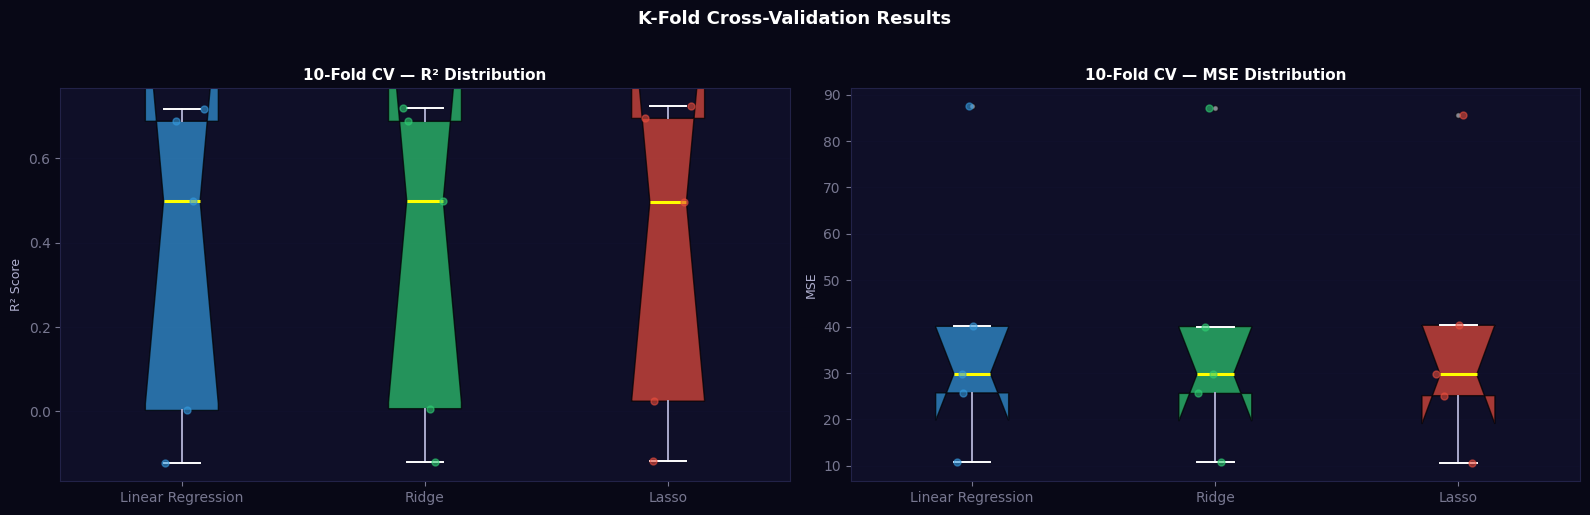

In [11]:
# CV score distribution — boxplot 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#080816')

for ax, metric, title, ylabel in zip(
    axes,
    ['r2',  'mse'],
    ['10-Fold CV — R² Distribution', '10-Fold CV — MSE Distribution'],
    ['R² Score', 'MSE']
):
    data  = [cv_results[n][metric] for n in pipelines]
    names = list(pipelines.keys())
    cols  = [MPAL[n] for n in names]

    bp = ax.boxplot(data, labels=names, patch_artist=True, notch=True,
                    medianprops=dict(color='yellow', lw=2.2),
                    whiskerprops=dict(color='#aaaacc', lw=1.4),
                    capprops=dict(color='white', lw=1.4),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor='white', alpha=0.5))
    for patch, col in zip(bp['boxes'], cols):
        patch.set_facecolor(col)
        patch.set_alpha(0.70)

    # Overlay individual fold points
    for i, (d, col) in enumerate(zip(data, cols), start=1):
        jitter = np.random.uniform(-0.1, 0.1, len(d))
        ax.scatter(i + jitter, d, color=col, s=25, alpha=0.6, zorder=5)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('K-Fold Cross-Validation Results', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part 6: Residual Analysis

In [12]:
# 6.1 Compute residuals 
residuals = {
    name: y_test.values - predictions[name]
    for name in pipelines
}

for name, res in residuals.items():
    _, sw_p = stats.shapiro(res[:50])   # Shapiro-Wilk on first 50 (test limit)
    print(f"{name:<22}  Residual mean={res.mean():.4f}  std={res.std():.4f}  "
          f"Shapiro p={sw_p:.4f}  {"→ Normal " if sw_p>0.05 else "→ Non-normal "}" )

Linear Regression       Residual mean=0.6441  std=5.2398  Shapiro p=0.0259  → Non-normal 
Ridge                   Residual mean=0.6406  std=5.2361  Shapiro p=0.0259  → Non-normal 
Lasso                   Residual mean=0.6582  std=5.2103  Shapiro p=0.0514  → Normal 


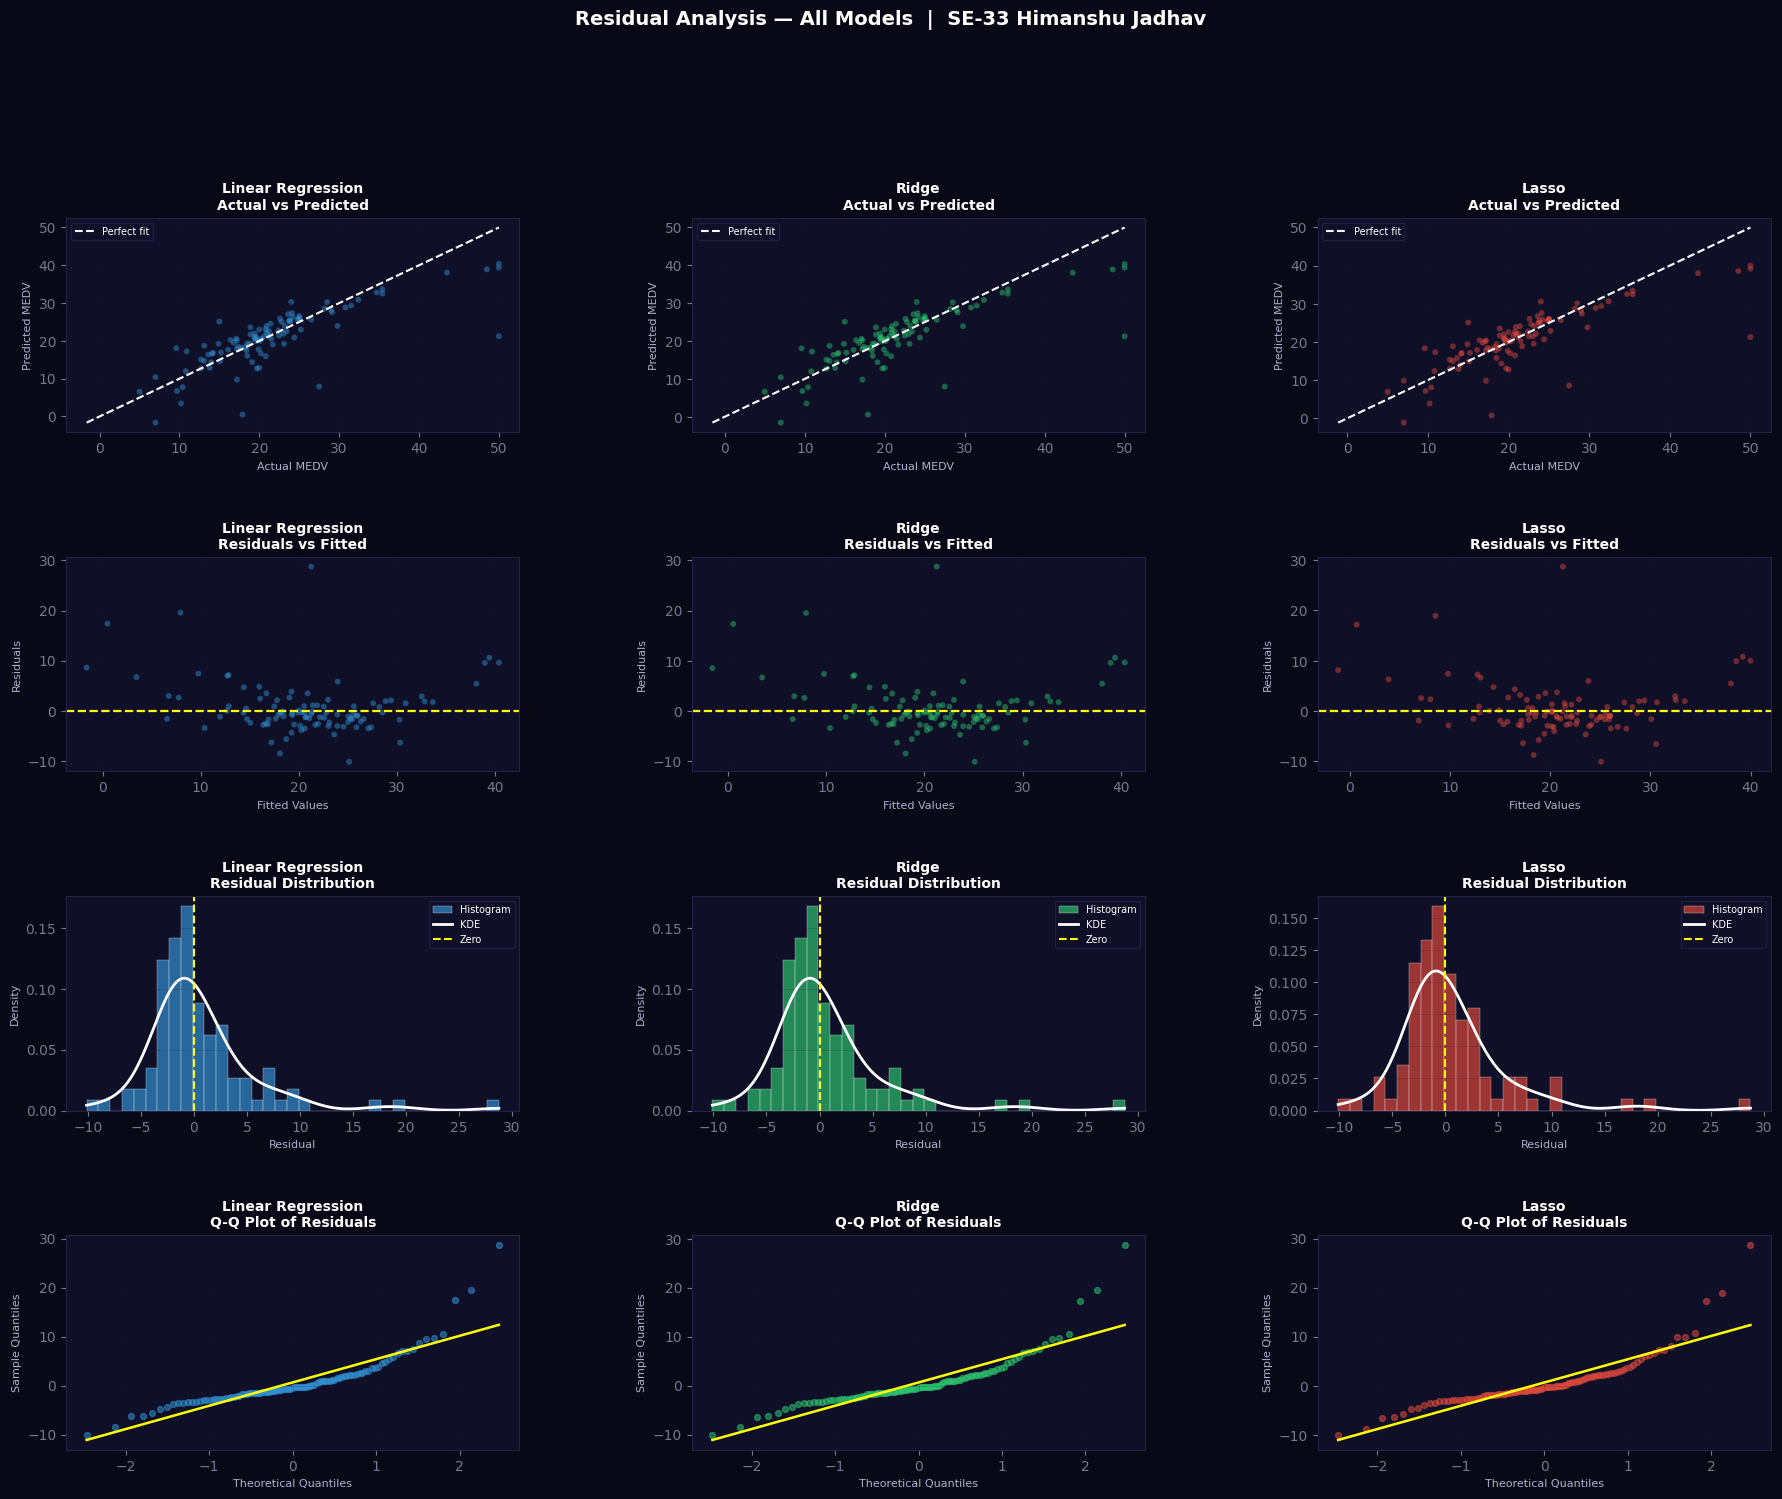

In [13]:
# Residual plot grid (3 models × 4 plots) 
fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#080816')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.58, wspace=0.38)

for col_idx, name in enumerate(pipelines):
    pred  = predictions[name]
    res   = residuals[name]
    color = MPAL[name]

    # Row 0: Actual vs Predicted 
    ax = fig.add_subplot(gs[0, col_idx])
    ax.scatter(y_test, pred, color=color, alpha=0.45, s=18, edgecolors='none')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'w--', lw=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nActual vs Predicted', fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual MEDV', fontsize=8)
    ax.set_ylabel('Predicted MEDV', fontsize=8)
    ax.legend(fontsize=7, labelcolor='white')
    ax.grid(True, alpha=0.25)

    # Row 1: Residuals vs Fitted 
    ax2 = fig.add_subplot(gs[1, col_idx])
    ax2.scatter(pred, res, color=color, alpha=0.45, s=18, edgecolors='none')
    ax2.axhline(0, color='yellow', lw=1.6, ls='--')
    ax2.set_title(f'{name}\nResiduals vs Fitted', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Fitted Values', fontsize=8)
    ax2.set_ylabel('Residuals', fontsize=8)
    ax2.grid(True, alpha=0.25)

    # Row 2: Residual Histogram + KDE 
    ax3 = fig.add_subplot(gs[2, col_idx])
    ax3.hist(res, bins=35, color=color, edgecolor='white', lw=0.3,
             alpha=0.65, density=True, label='Histogram')
    xr = np.linspace(res.min(), res.max(), 200)
    kde = stats.gaussian_kde(res)
    ax3.plot(xr, kde(xr), color='white', lw=2, label='KDE')
    ax3.axvline(0, color='yellow', lw=1.5, ls='--', label='Zero')
    ax3.set_title(f'{name}\nResidual Distribution', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Residual', fontsize=8)
    ax3.set_ylabel('Density', fontsize=8)
    ax3.legend(fontsize=7, labelcolor='white')
    ax3.grid(True, axis='y', alpha=0.25)

    # Row 3: Q-Q Plot 
    ax4 = fig.add_subplot(gs[3, col_idx])
    (osm, osr), (slope, intercept, _) = stats.probplot(res, dist='norm')
    ax4.scatter(osm, osr, color=color, s=18, alpha=0.5)
    ax4.plot(osm, slope*np.array(osm) + intercept, color='yellow', lw=1.8)
    ax4.set_title(f'{name}\nQ-Q Plot of Residuals', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Theoretical Quantiles', fontsize=8)
    ax4.set_ylabel('Sample Quantiles', fontsize=8)
    ax4.grid(True, alpha=0.25)

fig.suptitle('Residual Analysis — All Models  |  SE-33 Himanshu Jadhav',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('residuals.png', dpi=150, bbox_inches='tight', facecolor='#080816')
plt.show()

## Part 7: Model Comparison Dashboard 

In [14]:
# Coefficient comparison (regularisation effect) 
coef_data = {}
for name, pipe in pipelines.items():
    scaler = pipe.named_steps['scaler']
    coef_data[name] = pipe.named_steps['model'].coef_

coef_df = pd.DataFrame(coef_data, index=top_feats)
print('Model Coefficients (scaled features):')
print(coef_df.round(4).to_string())

Model Coefficients (scaled features):
         Linear Regression   Ridge   Lasso
LSTAT              -3.4418 -3.4286 -3.4286
RM                  3.8135  3.8017  3.7093
PTRATIO            -1.8106 -1.8079 -1.7006
INDUS               0.4750  0.4576  0.0000
TAX                -0.7960 -0.7919 -0.6443
NOX                -0.2989 -0.2990 -0.0003


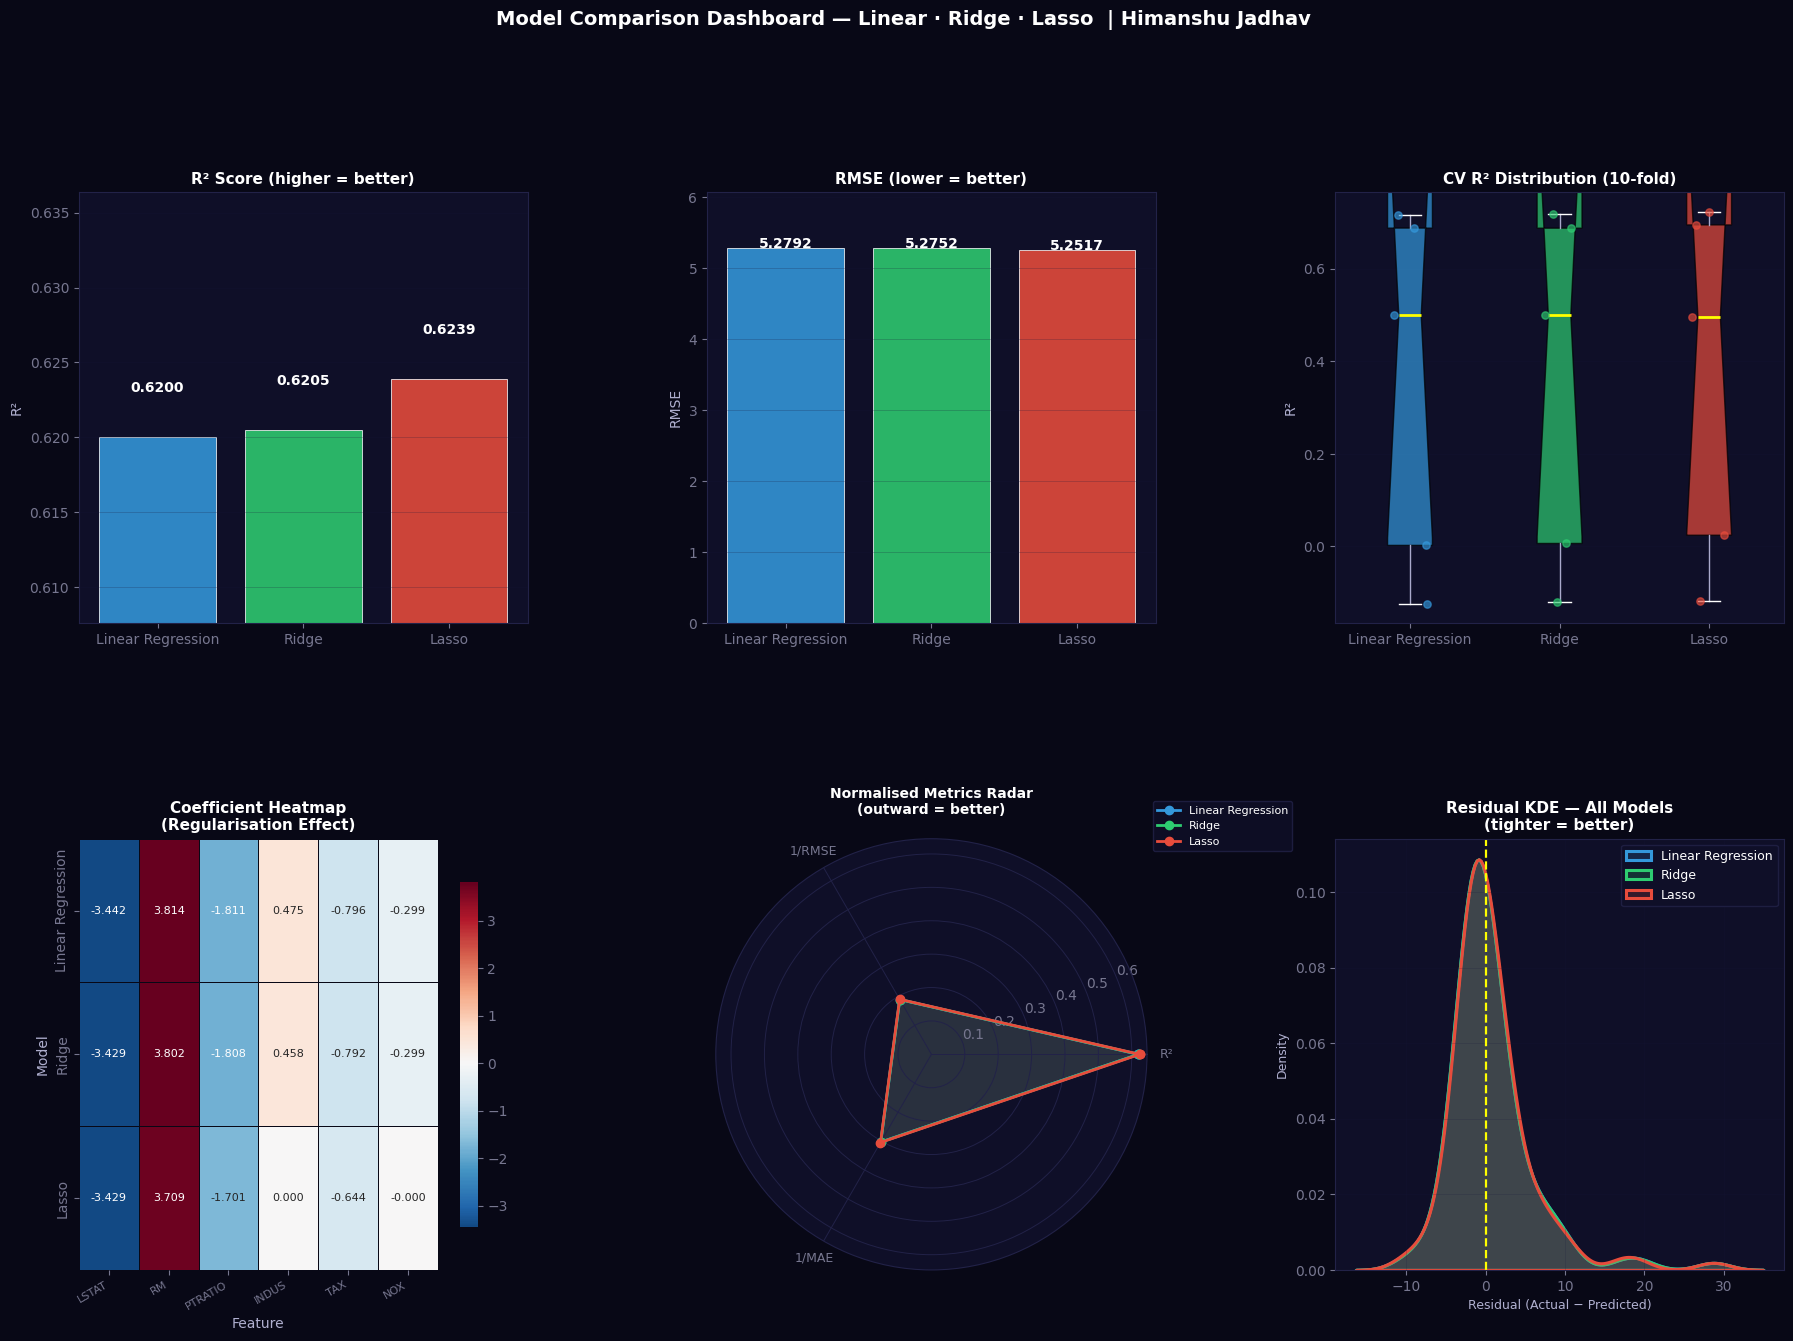

In [15]:
# Comparison dashboard 
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#080816')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)

model_names   = list(pipelines.keys())
model_colors  = [MPAL[n] for n in model_names]
x_pos         = np.arange(len(model_names))

# R² comparison 
ax1 = fig.add_subplot(gs[0, 0])
r2_vals = [results.loc[n, 'R²'] for n in model_names]
bars = ax1.bar(model_names, r2_vals, color=model_colors, edgecolor='white', lw=0.6, alpha=0.88)
for bar, v in zip(bars, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.003,
             f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('R² Score (higher = better)', fontsize=11, fontweight='bold')
ax1.set_ylabel('R²')
ax1.set_ylim(min(r2_vals)*0.98, min(max(r2_vals)*1.02, 1.0))
ax1.grid(True, axis='y', alpha=0.3)

# RMSE comparison
ax2 = fig.add_subplot(gs[0, 1])
rmse_vals = [results.loc[n, 'RMSE'] for n in model_names]
bars2 = ax2.bar(model_names, rmse_vals, color=model_colors, edgecolor='white', lw=0.6, alpha=0.88)
for bar, v in zip(bars2, rmse_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.002,
             f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('RMSE (lower = better)', fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE')
ax2.set_ylim(0, max(rmse_vals)*1.15)
ax2.grid(True, axis='y', alpha=0.3)

# CV R² boxplot overlay
ax3 = fig.add_subplot(gs[0, 2])
cv_r2_data = [cv_results[n]['r2'] for n in model_names]
bp = ax3.boxplot(cv_r2_data, labels=model_names, patch_artist=True, notch=True,
                 medianprops=dict(color='yellow', lw=2),
                 whiskerprops=dict(color='#aaaacc'), capprops=dict(color='white'),
                 flierprops=dict(marker='o', markersize=4, markerfacecolor='white', alpha=0.5))
for patch, col in zip(bp['boxes'], model_colors):
    patch.set_facecolor(col); patch.set_alpha(0.70)
for i, (d, col) in enumerate(zip(cv_r2_data, model_colors), start=1):
    ax3.scatter(np.full(len(d), i) + np.random.uniform(-0.12,0.12,len(d)),
                d, color=col, s=28, alpha=0.65, zorder=5)
ax3.set_title('CV R² Distribution (10-fold)', fontsize=11, fontweight='bold')
ax3.set_ylabel('R²'); ax3.grid(True, axis='y', alpha=0.3)

# Coefficient heatmap
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(coef_df.T, ax=ax4, annot=True, fmt='.3f', annot_kws={'size':8},
            cmap='RdBu_r', center=0, linewidths=0.5, linecolor='#080816',
            cbar_kws={'shrink':0.8})
ax4.set_title('Coefficient Heatmap\n(Regularisation Effect)', fontsize=11, fontweight='bold')
ax4.set_xlabel('Feature'); ax4.set_ylabel('Model')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Metrics radar / spider chart
ax5 = fig.add_subplot(gs[1, 1], polar=True)
metrics_radar = ['R²', 'RMSE', 'MAE']

# Normalise: R² → higher better (keep), RMSE/MAE → invert for radar
raw = {n: [results.loc[n,'R²'],
           1 / (results.loc[n,'RMSE'] + 1e-9),
           1 / (results.loc[n,'MAE']  + 1e-9)]
       for n in model_names}
radar_labels = ['R²', '1/RMSE', '1/MAE']
angles = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

for name, col in zip(model_names, model_colors):
    vals_r = raw[name] + raw[name][:1]
    ax5.plot(angles, vals_r, 'o-', color=col, lw=2, label=name)
    ax5.fill(angles, vals_r, color=col, alpha=0.10)

ax5.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
ax5.set_title('Normalised Metrics Radar\n(outward = better)', fontsize=10, fontweight='bold', pad=18)
ax5.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8, labelcolor='white')
ax5.grid(color='#222248', linewidth=0.7)

# Prediction error distribution─
ax6 = fig.add_subplot(gs[1, 2])
for name, col in zip(model_names, model_colors):
    sns.kdeplot(residuals[name], ax=ax6, color=col, linewidth=2.2,
                fill=True, alpha=0.18, label=name)
ax6.axvline(0, color='yellow', ls='--', lw=1.6)
ax6.set_title('Residual KDE — All Models\n(tighter = better)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Residual (Actual − Predicted)', fontsize=9)
ax6.set_ylabel('Density', fontsize=9)
ax6.legend(fontsize=9, labelcolor='white')
ax6.grid(True, alpha=0.25)

fig.suptitle('Model Comparison Dashboard — Linear · Ridge · Lasso  | Himanshu Jadhav',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('model_compare.png', dpi=150, bbox_inches='tight', facecolor='#080816')
plt.show()

In [16]:
cv_summary = pd.DataFrame({
    'CV R² Mean' : {n: cv_results[n]['r2'].mean().round(4) for n in model_names},
    'CV R² Std'  : {n: cv_results[n]['r2'].std().round(4)  for n in model_names},
    'CV MSE Mean': {n: cv_results[n]['mse'].mean().round(4) for n in model_names},
})
final = results.join(cv_summary).sort_values('R²', ascending=False)

print('═' * 86)
print('  FINAL MODEL RANKING (sorted by Test R²)')
print('═' * 86)
print(final.to_string())
print('═' * 86)
print(f' Best overall model : {final.index[0]}')
print('═' * 86)

══════════════════════════════════════════════════════════════════════════════════════
  FINAL MODEL RANKING (sorted by Test R²)
══════════════════════════════════════════════════════════════════════════════════════
                       R²      MSE    RMSE     MAE  CV R² Mean  CV R² Std  CV MSE Mean
Model                                                                                 
Lasso              0.6239  27.5799  5.2517  3.2799      0.3646     0.3474      38.2484
Ridge              0.6205  27.8276  5.2752  3.2943      0.3588     0.3494      38.6639
Linear Regression  0.6200  27.8702  5.2792  3.2961      0.3569     0.3511      38.7875
══════════════════════════════════════════════════════════════════════════════════════
 Best overall model : Lasso
══════════════════════════════════════════════════════════════════════════════════════
